In [83]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import copy
from skimage.metrics import structural_similarity, mean_squared_error

# Для изображения sar_3.jpg найти наиболее протяженный участок

In [84]:
image = cv2.imread('images/sar_3.jpg')
image_gray = cv2.imread('images/sar_3.jpg', cv2.IMREAD_GRAYSCALE)

In [85]:
blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)
canny = cv2.Canny(blurred, 50, 150, apertureSize=3)

In [86]:
line_image = copy.deepcopy(image)
h, w = image.shape[:2]
lines = cv2.HoughLines(canny, 1, np.pi / 180, 120)
max_line = None
max_len = 0

if lines is not None:
  for i in range(len(lines)):
    rho = lines[i][0][0]
    theta = lines[i][0][1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    len_lim = 1000
    pt1 = (int(x0 + len_lim * (-b)), int(y0 + len_lim * (a)))
    pt2 = (int(x0 - len_lim * (-b)), int(y0 - len_lim * (a)))
    ret, clipped_pt1, clipped_pt2 = cv2.clipLine((0, 0, w, h), pt1, pt2)
    if ret:
      pt1, pt2 = clipped_pt1, clipped_pt2
    length = np.hypot(pt2[0] - pt1[0], pt2[1] - pt1[1])
    cv2.line(line_image, pt1, pt2, (255, 0, 0), 1, cv2.LINE_AA)
    if length > max_len:
      max_len = length
      max_line = (pt1, pt2, rho, theta)

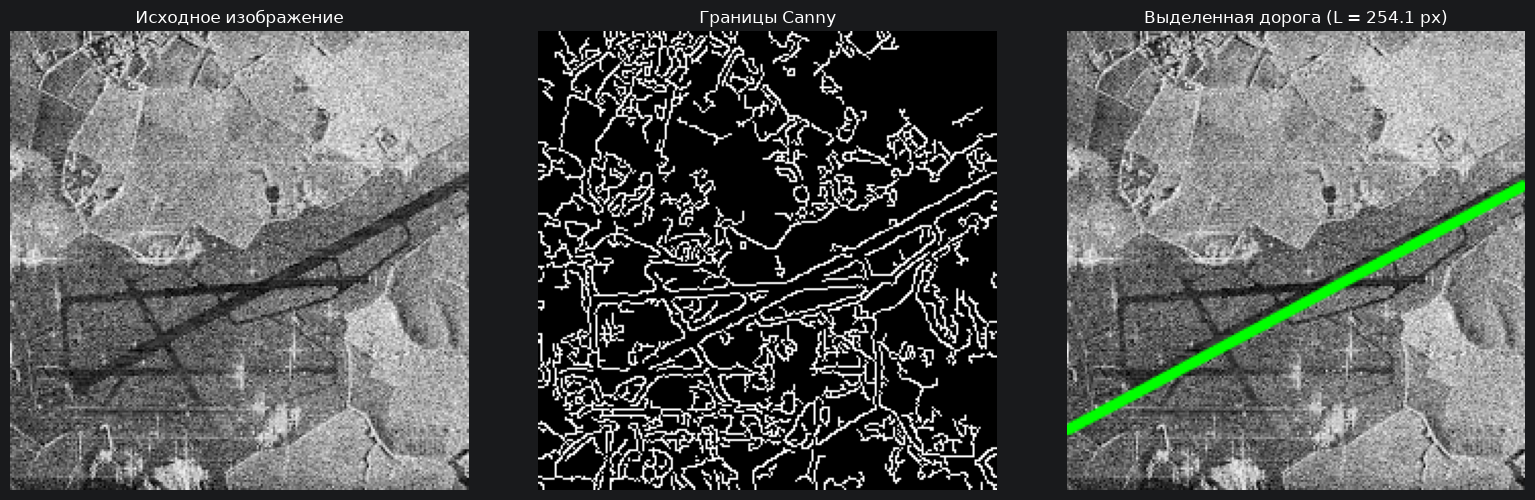

In [87]:
best_line_image = image.copy()

if max_line is not None:
  pt1, pt2, rho, theta = max_line
  cv2.line(best_line_image, pt1, pt2, (0, 255, 0), 3, cv2.LINE_AA)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(image_gray, cmap='gray')
axs[0].set_title('Исходное изображение')
axs[0].axis('off')
axs[1].imshow(canny, cmap='gray')
axs[1].set_title('Границы Canny')
axs[1].axis('off')
axs[2].imshow(cv2.cvtColor(best_line_image, cv2.COLOR_BGR2RGB))
axs[2].set_title(f'Выделенная дорога (L = {max_len:.1f} px)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

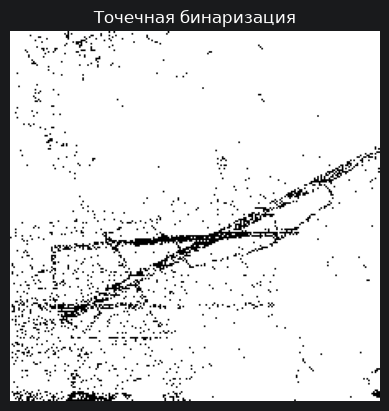

In [88]:
import copy

bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.imshow(bin_img, cmap='gray')
plt.title('Точечная бинаризация')
plt.axis('off')
plt.show()

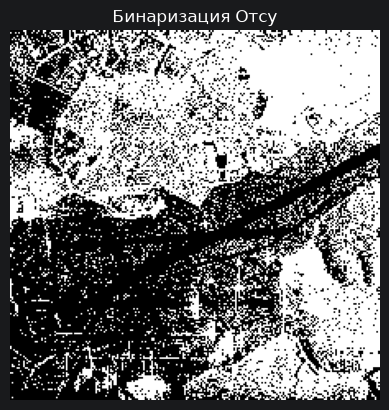

In [89]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(th2, cmap='gray')
plt.title('Бинаризация Отсу')
plt.axis('off')
plt.show()

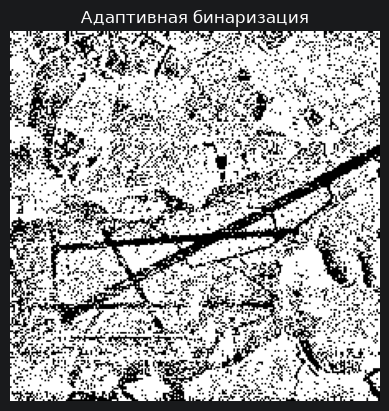

In [90]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)

plt.imshow(th3, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')
plt.show()

In [91]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5,0.0)

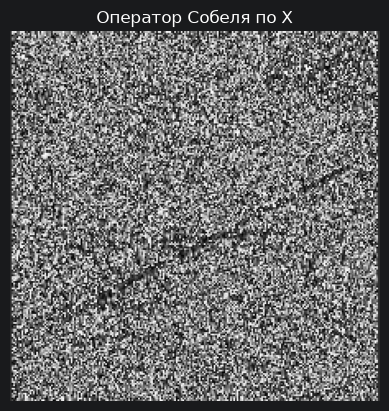

In [92]:
plt.imshow((grad_x - grad_x.min())*255, cmap='gray')
plt.title('Оператор Собеля по Х')
plt.axis('off')
plt.show()

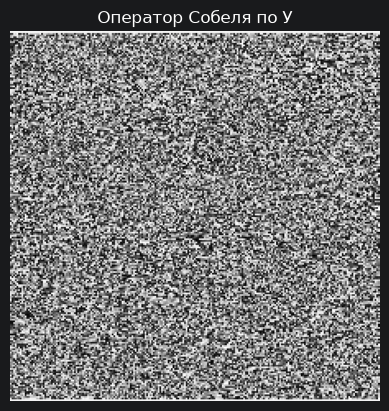

In [93]:
plt.imshow((grad_y - grad_y.min())*255, cmap='gray')
plt.title('Оператор Собеля по У')
plt.axis('off')
plt.show()

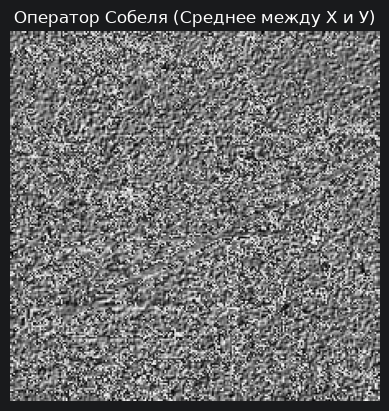

In [94]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)

plt.imshow((grad - grad.min())*255, cmap='gray')
plt.title('Оператор Собеля (Среднее между Х и У)')
plt.axis('off')
plt.show()

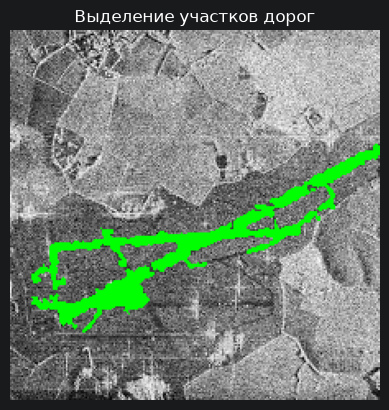

In [95]:
blur = cv2.GaussianBlur(bin_img, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 55, 2)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
image_line_road = image.copy()

road_mask = np.zeros_like(image_gray)
image_with_roads = image.copy()

if contours:
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 500:
            cv2.drawContours(image_line_road, [contour], -1, (255, 0, 0), 1)
            cv2.fillPoly(road_mask, [contour], 255)
            cv2.fillPoly(image_with_roads, [contour], (0, 255, 0))

road = cv2.bitwise_and(image, image,mask=road_mask)

plt.imshow(image_with_roads, cmap='gray')
plt.title('Выделение участков дорог')
plt.axis('off')
plt.show()